In [1]:
import numpy as np
import pandas as pd


from tabularepimdl.SimpleTransition_Vec_Encode import SimpleTransition_Vec_Encode
from tabularepimdl.SimpleInfection_Vec_Encode import SimpleInfection_Vec_Encode
from tabularepimdl.SimpleObservationProcess_Vec_Encode import SimpleObservationProcess_Vec_Encode

from tabularepimdl.EpiModel_Vec_Encode1_2 import EpiModel_Vec_Encode_1_2

%matplotlib inline
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
np.random.seed(2) #just to guarantee a same epidemic each time of run
infection_rate = 0.5
transition_rate = 0.25
infstate_compartments = ['S', 'I', 'R']
column_compartments =  ['S', 'I', 'R']
obs_col_all_categories = ['U', 'I', 'P']
#start with one person infected and everyone else susceptible.
population = pd.DataFrame({
    'InfState' : pd.Categorical(['S','I'], categories=['S','I','R']),
    'N' : [999, 1],
    'T': 0.0
})
population

,InfState,N,T
0,S,999,0.0
1,I,1,0.0


#### Deterministic Model

In [ ]:
#Vec rules
infect_rule_vec = SimpleInfection_Vec_Encode(beta=infection_rate, column='InfState', s_st='S', i_st='I', inf_to='I', infstate_compartments=infstate_compartments, column_categories=column_compartments)
recover_rule_vec = SimpleTransition_Vec_Encode(column='InfState', from_st='I', to_st='R', rate=transition_rate, infstate_compartments=infstate_compartments, column_categories=column_compartments)
determ_epi_mdl_vec1 = EpiModel_Vec_Encode_1_2(init_state = population ,rules=[[infect_rule_vec, recover_rule_vec]], compartment_col = 'InfState')

In [4]:
for i in range(400):
    determ_epi_mdl_vec1.do_timestep(dt=0.25)

In [5]:
determ_full_history_df = determ_epi_mdl_vec1._covnert_list_of_arrays_to_df(determ_epi_mdl_vec1._full_epi_list)

In [6]:
determ_epi_fig = px.line(determ_full_history_df, x="T", y="N", color="InfState", title='Population infections history deterministic')
determ_epi_fig.show()

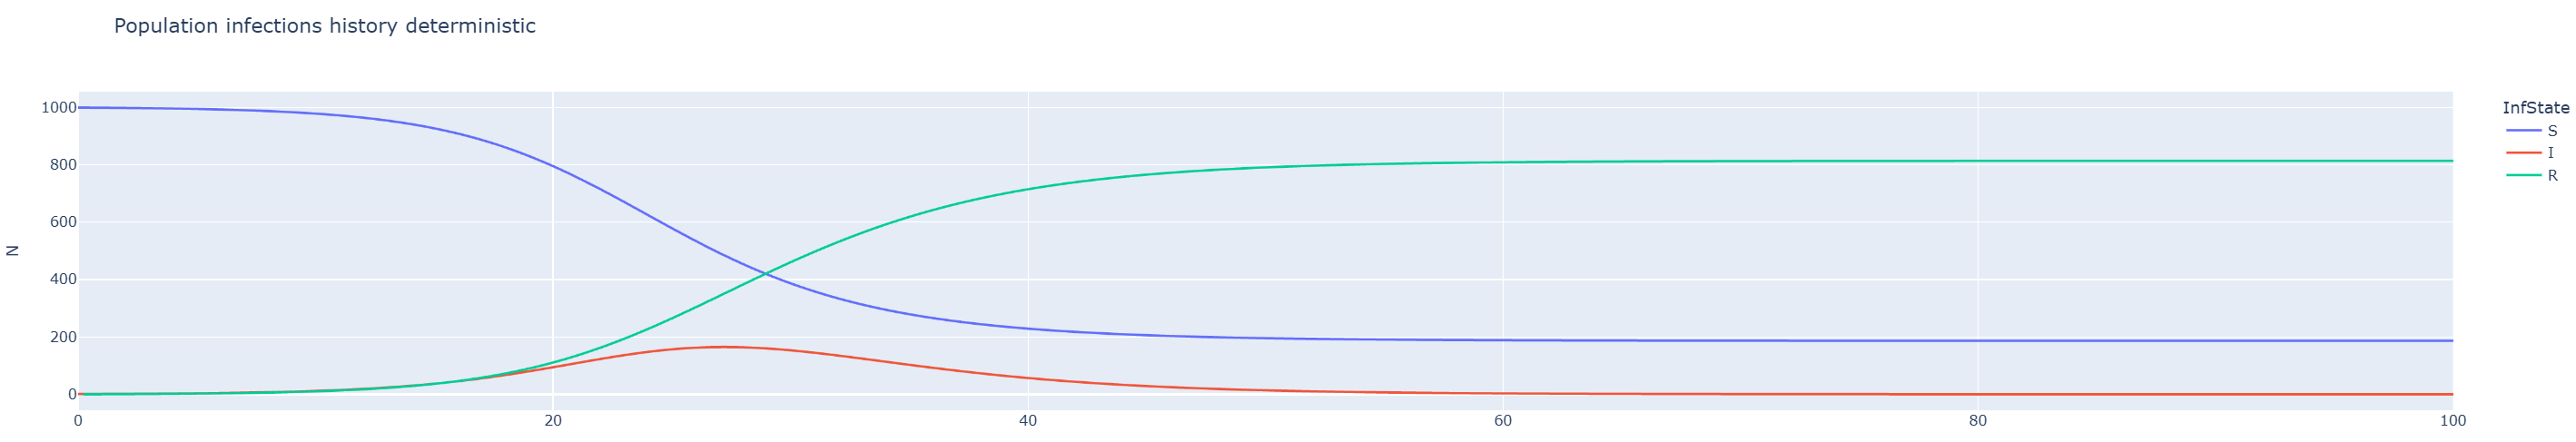

#### Stochastic Model

In [7]:
stoch_epi_mdl_vec1 = EpiModel_Vec_Encode_1_2(init_state=population, rules = [[infect_rule_vec, recover_rule_vec]], stoch_policy="stochastic", compartment_col = 'InfState')

In [8]:
for i in range(400):
    stoch_epi_mdl_vec1.do_timestep(dt=0.25)

In [9]:
stoch_full_history_df = stoch_epi_mdl_vec1._covnert_list_of_arrays_to_df(stoch_epi_mdl_vec1._full_epi_list)

In [10]:
stoch_epi_fig = px.line(stoch_full_history_df, x="T", y="N", color="InfState", title='Population infections history stochastic')
stoch_epi_fig.show()

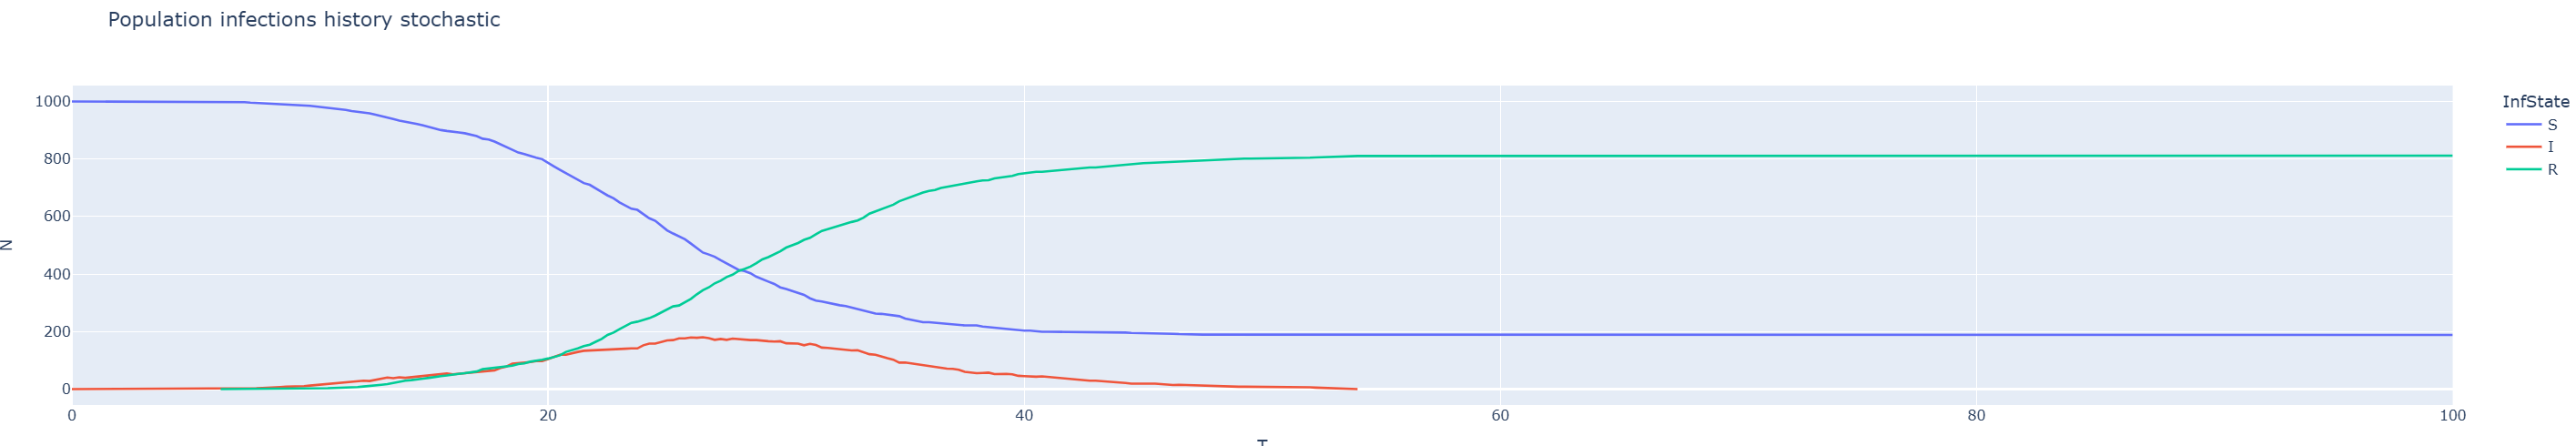

In [11]:
#Do 20 simulations with stochastic process concatenating together. 
all_sims = pd.DataFrame()

for i in range(20):
    stoch_epi_mdl_vec1.Reset()
    for j in range(400):
        stoch_epi_mdl_vec1.do_timestep(dt=0.25)
    tmp_df = stoch_epi_mdl_vec1._covnert_list_of_arrays_to_df(stoch_epi_mdl_vec1._full_epi_list) #convert 
    tmp_df['sim'] = i
    all_sims = pd.concat([all_sims,tmp_df]) #save each full_epi from simulations
    
all_sims = all_sims.reset_index(drop=True)

In [12]:
all_sims_infected_people = all_sims[all_sims['InfState']=='I'] #extract infected people data
#Plot each simulation's infected population data
stoch_simple_sir_fig = px.line(all_sims_infected_people, x="T", y="N", color="sim", title='infected population in 100 time units')
stoch_simple_sir_fig.show()

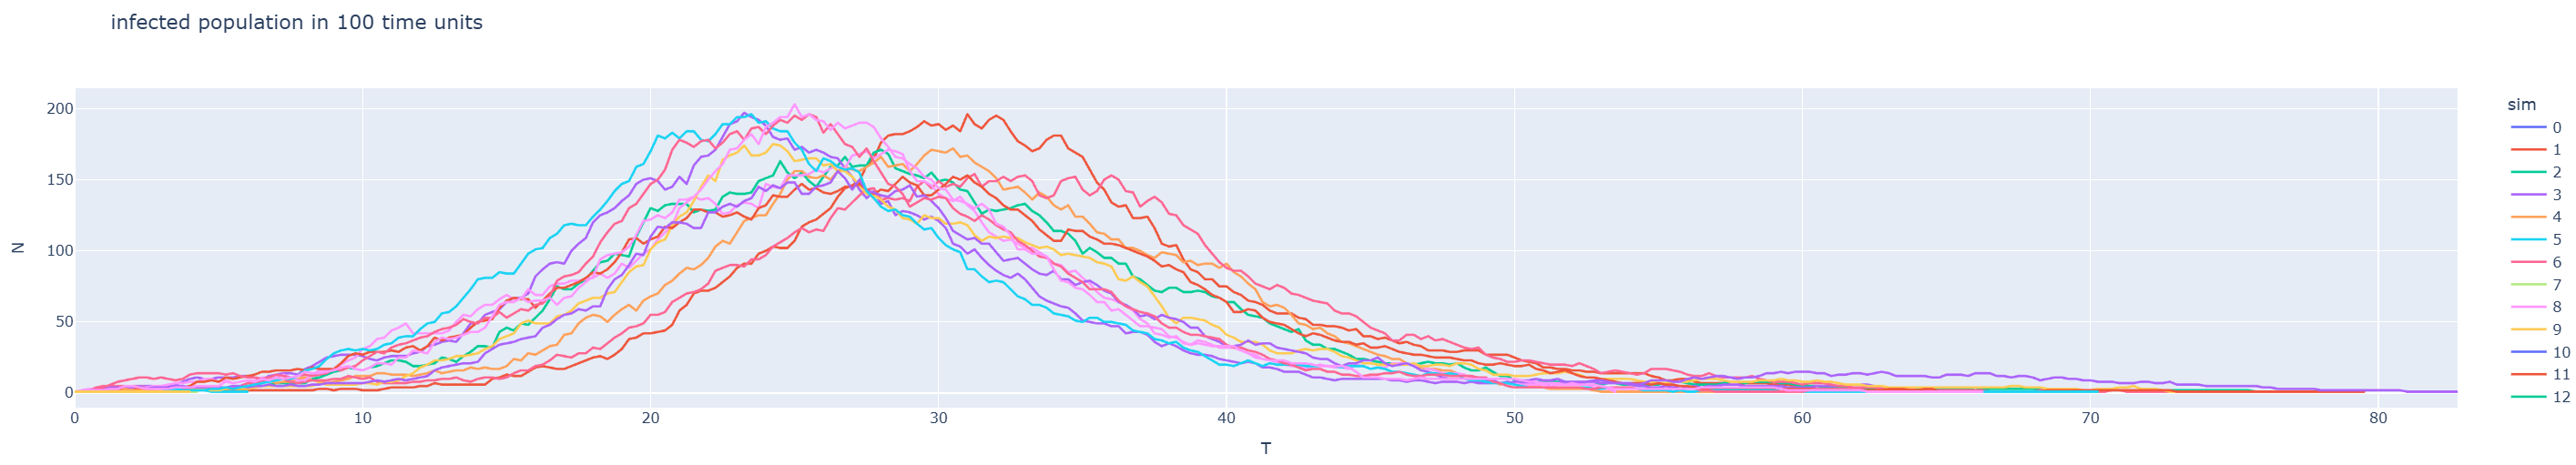

#### Adding an Stochastic Observation Process to a Determinsitic Model

In [13]:
#Creeate a hospitalization column with everyone unobserved
population_new = population.copy()
population_new['Hosp'] = 'U'
population_new

,InfState,N,T,Hosp
0,S,999,0.0,U
1,I,1,0.0,U


In [ ]:
#Create the hospitalization rule. Everyone has a 5% chance of being hospitalized per day infected
hosp_stoch_rule_vec1 = SimpleObservationProcess_Vec_Encode(source_col="InfState",source_state="I", obs_col="Hosp", rate=0.05, stochastic=True, infstate_compartments=infstate_compartments, obs_col_all_categories=obs_col_all_categories)

#Create the epi model
hosp_obs_mdl_vec1 = EpiModel_Vec_Encode_1_2(init_state = population_new, rules = [ [infect_rule_vec, recover_rule_vec], [hosp_stoch_rule_vec1] ], compartment_col = 'InfState')
iter = 400
for i in range(iter):
    hosp_obs_mdl_vec1.do_timestep(dt=0.25)

In [15]:
hosp_res_vec1 = hosp_obs_mdl_vec1._covnert_list_of_arrays_to_df(hosp_obs_mdl_vec1._full_epi_list)
# Floor the 'T' values
hosp_res_vec1['T'] = np.floor(hosp_res_vec1['T'])

In [16]:
#Sum of N where Hosp == "I", Sum of N where InfState == "I"
hosp_inf = hosp_res_vec1.groupby('T').agg(
    Hosp_Incident=pd.NamedAgg(column='N', aggfunc=lambda x: (x[hosp_res_vec1['Hosp'] == 'I']).sum()), 
    InfState_Infect =  pd.NamedAgg(column='N', aggfunc=lambda x: (x[hosp_res_vec1['InfState'] == 'I']).sum()) 
).reset_index()
hosp_inf.head()

,T,Hosp_Incident,InfState_Infect
0,0.0,0.0,4.402402
1,1.0,0.0,5.647092
2,2.0,0.0,7.241346
3,3.0,0.0,9.281824
4,4.0,0.0,11.890943


In [17]:
# Create a image with two separate plots (one for Hosp, one for I)
fig_hosp_infstate = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Hosp_Incident", "InfState_Infect"),
    shared_xaxes=True
)

# Add the trace for Hosp to the first subplot (left)
fig_hosp_infstate.add_trace(
    go.Scatter(x=hosp_inf['T'], y=hosp_inf['Hosp_Incident'], mode='lines', name='Hosp Incident-observed Count',
               line=dict(color='blue')),
    row=1, col=1
)

# Add the trace for InfState to the second subplot (right)
fig_hosp_infstate.add_trace(
    go.Scatter(x=hosp_inf['T'], y=hosp_inf['InfState_Infect'], mode='lines', name='InfState Infected Count',
               line=dict(color='red')),
    row=1, col=2
)

# Update layout for the entire figure
fig_hosp_infstate.update_layout(
    title={
        'text': "Hosp_Incident and InfState_Infect over Time",
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title="Time (T)",
    xaxis2_title="Time (T)",
)

# Left subplot: y-axis for Hosp
fig_hosp_infstate.update_yaxes(title_text="Count (Hosp==Incident-observed)", row=1, col=1)

# Right subplot: y-axis for I
fig_hosp_infstate.update_yaxes(title_text="Count (InfState==Infected)", row=1, col=2)

# Show the plot
fig_hosp_infstate.show()


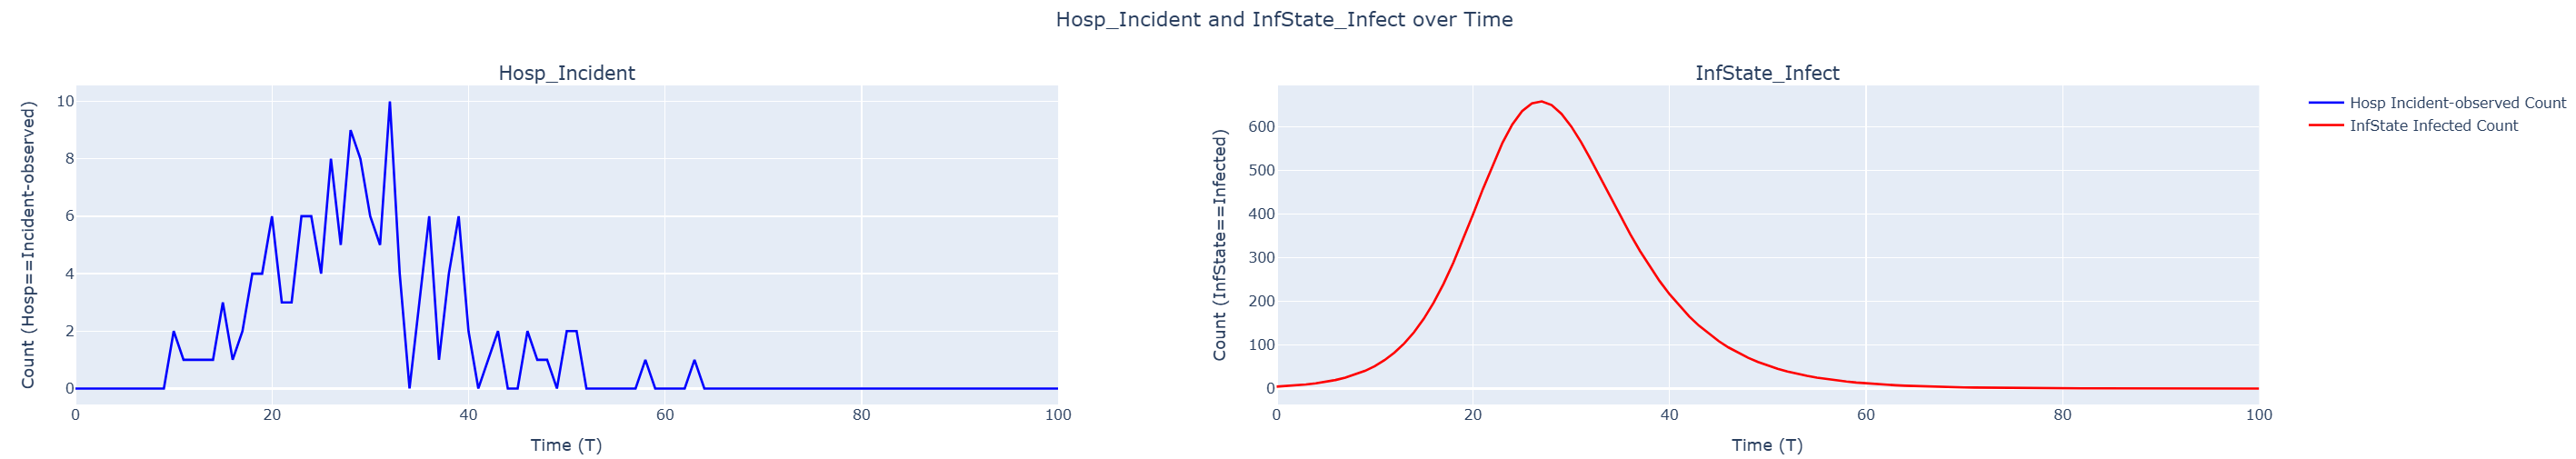